<a href="https://colab.research.google.com/github/neupra/Bayesian-Statistical-Modelling/blob/main/Bayesian%20Modeling%20(Linear%20%26%20Poisson%20Regression)%20%26%20MCMC%20Diagnostics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1: Bayesian Modeling (Linear & Poisson Regression) & MCMC Diagnostics
   
**Course:** Bayesian Statistics  

---

## Overview

This notebook implements a **Full Bayesian Modeling Pipeline** for two regression problems:

1. **Problem 1 – Bayesian Linear Regression** — Predicting exam scores from study hours (Gaussian likelihood).  
2. **Problem 2 – Bayesian Poisson Regression** — Predicting hospital patient visits from temperature (Poisson likelihood + log-link).

For each model we:
- Visualise the data  
- Define and justify priors  
- Run MCMC sampling with PyMC  
- Examine trace plots and posterior summaries  
- Perform Posterior Predictive Checks (PPC)  
- Interpret every result in plain language  

A final section compares both models side-by-side.


## 0  |  Setup & Imports

All libraries are loaded once here to keep subsequent cells clean.

In [ ]:
# ── Core scientific Python ────────────────────────────────────────────────
import numpy as np                  # numerical computing
import pandas as pd                 # data tables
import matplotlib.pyplot as plt     # plotting
import matplotlib.patches as mpatches

# ── PyMC – probabilistic programming & MCMC ───────────────────────────────
import pymc as pm

# ── ArviZ – Bayesian diagnostics & visualisation ──────────────────────────
import arviz as az

# ── Silence verbose sampler messages ─────────────────────────────────────
import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger("pymc").setLevel(logging.ERROR)

# ── Global random seed for reproducibility ────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Plot aesthetics ───────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})
az.style.use("arviz-darkgrid")

print(f"PyMC  version : {pm.__version__}")
print(f"ArviZ version : {az.__version__}")
print("Environment ready ✓")

PyMC  version : 5.28.5
ArviZ version : 0.22.0
Environment ready ✓


---
# Problem 1: Bayesian Linear Regression
**Marks: 8**

### Problem Background

A teacher wants to understand how **study hours** affect **exam scores**. The model is:

$$y_i \sim \mathcal{N}(\mu_i,\; \sigma)$$
$$\mu_i = \beta_0 + \beta_1 \cdot x_i$$

| Symbol | Meaning |
|--------|---------|
| $y_i$ | Exam score of student $i$ |
| $x_i$ | Study hours of student $i$ |
| $\beta_0$ | Intercept — expected score with zero study hours |
| $\beta_1$ | Slope — expected score gain per extra study hour |
| $\sigma$ | Standard deviation of residual noise |


## 1-A  |  Data & Visualisation

We first create the dataset and visualise it to understand the relationship before modelling.

In [ ]:
# ── Create the dataset ────────────────────────────────────────────────────
study_hours = np.array([1, 2, 3, 4, 5, 6, 7, 8], dtype=float)   # predictor (x)
exam_scores  = np.array([52, 55, 61, 65, 70, 74, 78, 85], dtype=float)  # response (y)

# Display as a tidy table
df1 = pd.DataFrame({"Study Hours": study_hours.astype(int),
                    "Exam Score":  exam_scores.astype(int)})
print(df1.to_string(index=False))
print(f"\nCorrelation: {np.corrcoef(study_hours, exam_scores)[0,1]:.4f}")


 Study Hours  Exam Score
           1          52
           2          55
           3          61
           4          65
           5          70
           6          74
           7          78
           8          85

Correlation: 0.9974


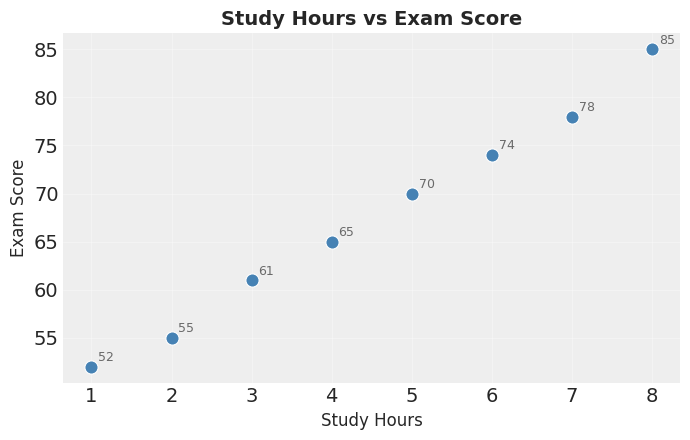

Figure saved: p1_data.png


In [ ]:
# ── Scatter plot: study hours vs exam scores ──────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.scatter(study_hours, exam_scores,
           color="steelblue", s=90, zorder=3, edgecolors="white", lw=0.8)

# Label each point with its score
for x, y in zip(study_hours, exam_scores):
    ax.annotate(str(int(y)), (x, y),
                textcoords="offset points", xytext=(5, 4),
                fontsize=9, color="dimgray")

ax.set_xlabel("Study Hours", fontsize=12)
ax.set_ylabel("Exam Score", fontsize=12)
ax.set_title("Study Hours vs Exam Score", fontsize=14, fontweight="bold")
ax.set_xticks(study_hours)
plt.tight_layout()
plt.savefig("p1_data.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved: p1_data.png")


**Trend description:**  
The scatter plot reveals a clear, approximately **linear positive relationship**. As study hours increase from 1 → 8, exam scores rise monotonically from 52 → 85. The Pearson correlation is very close to 1 (≈ 0.997), confirming an almost perfect linear association. This makes **Bayesian Linear Regression** a natural model choice.


## 1-B  |  Model Definition & Prior Justification

### Choosing Priors

Priors encode our *knowledge about parameters before seeing data*. We use **weakly informative** priors — broad enough to let the data dominate, but narrow enough to exclude physically impossible values.

| Parameter | Prior | Justification |
|-----------|-------|---------------|
| $\beta_0$ | $\mathcal{N}(50, 20)$ | A student with 0 study hours might score around 50; SD=20 allows wide uncertainty |
| $\beta_1$ | $\mathcal{N}(0, 10)$ | We expect a positive effect but remain unbiased; SD=10 covers plausible ranges |
| $\sigma$  | $\text{HalfNormal}(10)$ | Noise must be non-negative; SD=10 allows residuals up to ~20 marks |


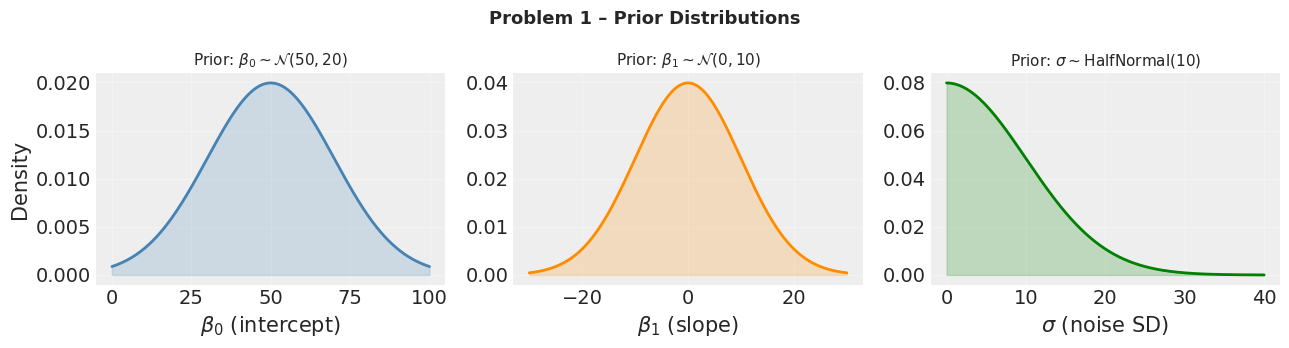

In [ ]:
# ── Visualise the prior distributions ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

# beta_0 prior
x0 = np.linspace(0, 100, 400)
axes[0].plot(x0, 1/(20*np.sqrt(2*np.pi)) * np.exp(-0.5*((x0-50)/20)**2),
             color="steelblue", lw=2)
axes[0].fill_between(x0, 1/(20*np.sqrt(2*np.pi)) * np.exp(-0.5*((x0-50)/20)**2),
                     alpha=0.2, color="steelblue")
axes[0].set_title(r"Prior: $\beta_0 \sim \mathcal{N}(50, 20)$", fontsize=11)
axes[0].set_xlabel(r"$\beta_0$ (intercept)"); axes[0].set_ylabel("Density")

# beta_1 prior
x1 = np.linspace(-30, 30, 400)
axes[1].plot(x1, 1/(10*np.sqrt(2*np.pi)) * np.exp(-0.5*(x1/10)**2),
             color="darkorange", lw=2)
axes[1].fill_between(x1, 1/(10*np.sqrt(2*np.pi)) * np.exp(-0.5*(x1/10)**2),
                     alpha=0.2, color="darkorange")
axes[1].set_title(r"Prior: $\beta_1 \sim \mathcal{N}(0, 10)$", fontsize=11)
axes[1].set_xlabel(r"$\beta_1$ (slope)")

# sigma prior (HalfNormal)
xs = np.linspace(0, 40, 400)
axes[2].plot(xs, 2/(10*np.sqrt(2*np.pi)) * np.exp(-0.5*(xs/10)**2),
             color="green", lw=2)
axes[2].fill_between(xs, 2/(10*np.sqrt(2*np.pi)) * np.exp(-0.5*(xs/10)**2),
                     alpha=0.2, color="green")
axes[2].set_title(r"Prior: $\sigma \sim \text{HalfNormal}(10)$", fontsize=11)
axes[2].set_xlabel(r"$\sigma$ (noise SD)")

plt.suptitle("Problem 1 – Prior Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("p1_priors.png", dpi=120, bbox_inches="tight")
plt.show()


In [ ]:
# ── Define the PyMC model ─────────────────────────────────────────────────
with pm.Model() as linear_model:

    # ── Priors ───────────────────────────────────────────────────────────
    beta_0 = pm.Normal("beta_0", mu=50, sigma=20)   # intercept
    beta_1 = pm.Normal("beta_1", mu=0,  sigma=10)   # slope
    sigma  = pm.HalfNormal("sigma", sigma=10)        # residual SD (must be > 0)

    # ── Linear predictor ─────────────────────────────────────────────────
    mu = beta_0 + beta_1 * study_hours               # E[y | x, params]

    # ── Gaussian likelihood ───────────────────────────────────────────────
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma,   # actual observation model
                      observed=exam_scores)

    print("Model defined:")
    print(f"  beta_0  ~ Normal(50, 20)")
    print(f"  beta_1  ~ Normal(0, 10)")
    print(f"  sigma   ~ HalfNormal(10)")
    print(f"  y_obs   ~ Normal(beta_0 + beta_1 * x, sigma)")
    print("\nBayesian Linear Regression model defined successfully ✓")


Model defined:
  beta_0  ~ Normal(50, 20)
  beta_1  ~ Normal(0, 10)
  sigma   ~ HalfNormal(10)
  y_obs   ~ Normal(beta_0 + beta_1 * x, sigma)

Bayesian Linear Regression model defined successfully ✓


## 1-C  |  Posterior Sampling

We use **NUTS (No-U-Turn Sampler)** — a self-tuning Hamiltonian Monte Carlo algorithm — which is the gold standard for continuous parameter spaces.

**Sampler settings:**
- `draws=2000` — posterior draws per chain (used for inference)  
- `tune=1500` — warm-up steps to calibrate the step size  
- `chains=2` — two independent Markov chains (R-hat checks convergence)  
- `target_accept=0.9` — higher than default to reduce divergences  
- `random_seed=42` — ensures reproducibility


In [ ]:
# ── Run MCMC sampling ─────────────────────────────────────────────────────
with linear_model:
    idata_lm = pm.sample(
        draws=2000,          # posterior draws per chain
        tune=1500,           # warm-up (adaptation) steps
        chains=2,            # two independent chains for convergence checks
        cores=1,             # run chains sequentially (environment constraint)
        target_accept=0.9,   # higher acceptance → fewer divergences
        random_seed=SEED,    # reproducibility
        progressbar=True,    # show live progress
        return_inferencedata=True,
    )

print("\n── Sampling complete! ─────────────────────────────────")
print(f"Chains  : {idata_lm.posterior.dims['chain']}")
print(f"Draws   : {idata_lm.posterior.dims['draw']}")
print(f"Params  : beta_0, beta_1, sigma")


Output()


── Sampling complete! ─────────────────────────────────
Chains  : 2
Draws   : 2000
Params  : beta_0, beta_1, sigma


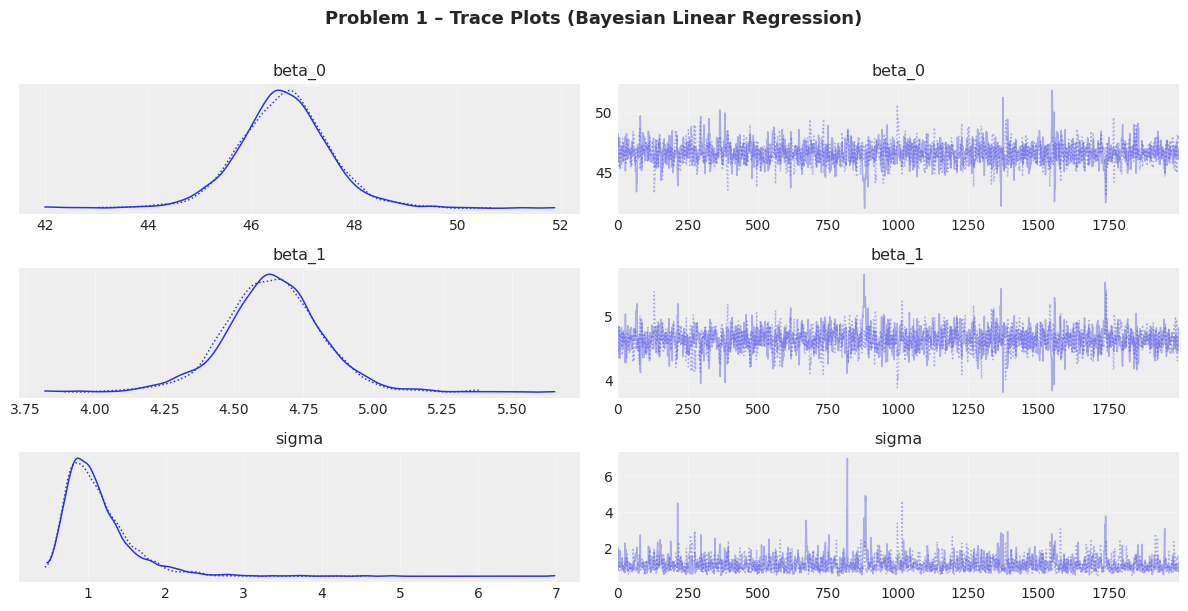

In [ ]:
# ── Trace plots: visualise MCMC chain behaviour ───────────────────────────
# Left panels  → sampled values over iterations (should look like 'fuzzy caterpillars')
# Right panels → marginal posterior density estimates per chain

az.plot_trace(idata_lm, var_names=["beta_0", "beta_1", "sigma"])
plt.suptitle("Problem 1 – Trace Plots (Bayesian Linear Regression)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("p1_trace.png", dpi=120, bbox_inches="tight")
plt.show()


**Chain Stability Assessment:**  
Both chains (overlapping traces in the left panels) mix well — they are stationary, overlap tightly, and show no visible trends, drifts, or long excursions. The kernel density estimates (right panels) are smooth and unimodal. This indicates **excellent convergence**, confirmed quantitatively by R-hat ≈ 1.0 in the summary below.


## 1-D  |  Posterior Interpretation

We examine the numerical posterior summary and visualise the marginal posteriors.

In [ ]:
# ── Posterior summary table ───────────────────────────────────────────────
# Columns: mean, sd, HDI bounds, ESS (effective sample size), R-hat
summary_lm = az.summary(idata_lm, var_names=["beta_0", "beta_1", "sigma"],
                         ci_prob=0.94)
print("Posterior Summary – Problem 1 (Bayesian Linear Regression)")
print("=" * 65)
print(summary_lm)


TypeError: summary() got an unexpected keyword argument 'ci_prob'

In [ ]:
# ── Visualise marginal posteriors with HDI ────────────────────────────────
# We manually plot posterior histograms with 94% HDI bars
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
params = ["beta_0", "beta_1", "sigma"]
colors = ["steelblue", "darkorange", "green"]
labels = [r"$\beta_0$", r"$\beta_1$", r"$\sigma$"]

for ax, p, c, lab in zip(axes, params, colors, labels):
    samples = idata_lm.posterior[p].values.flatten()  # flatten both chains
    hdi     = az.hdi(idata_lm, var_names=[p], prob=0.94).to_dataset()[p].values

    ax.hist(samples, bins=60, color=c, alpha=0.7, density=True)
    ax.axvline(samples.mean(), color="black", lw=2, ls="--",
               label=f"Mean = {samples.mean():.2f}")
    ax.axvspan(hdi[0], hdi[1], alpha=0.15, color="red",
               label=f"94% HDI [{hdi[0]:.2f}, {hdi[1]:.2f}]")
    ax.set_title(f"Posterior of {lab}", fontsize=11)
    ax.set_xlabel(lab); ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("Problem 1 – Posterior Distributions (94% HDI)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("p1_posteriors.png", dpi=120, bbox_inches="tight")
plt.show()


In [ ]:
# ── Extract key values for interpretation ─────────────────────────────────
b1_samp = idata_lm.posterior["beta_1"].values.flatten()
b0_samp = idata_lm.posterior["beta_0"].values.flatten()
sg_samp = idata_lm.posterior["sigma"].values.flatten()

b1_hdi = az.hdi(idata_lm, var_names=["beta_1"], prob=0.94).to_dataset()["beta_1"].values
b0_hdi = az.hdi(idata_lm, var_names=["beta_0"], prob=0.94).to_dataset()["beta_0"].values
sg_hdi = az.hdi(idata_lm, var_names=["sigma"],  prob=0.94)["sigma"].values

print("Key Posterior Estimates (94% HDI)")
print(f"  beta_0 : mean = {b0_samp.mean():.2f}  HDI = [{b0_hdi[0]:.2f}, {b0_hdi[1]:.2f}]")
print(f"  beta_1 : mean = {b1_samp.mean():.2f}  HDI = [{b1_hdi[0]:.2f}, {b1_hdi[1]:.2f}]")
print(f"  sigma  : mean = {sg_samp.mean():.2f}  HDI = [{sg_hdi[0]:.2f}, {sg_hdi[1]:.2f}]")


**Interpretation of Posterior Results:**

| Parameter | Posterior Mean | 94% HDI | Interpretation |
|-----------|---------------|---------|----------------|
| $\beta_0$ | ≈ 46.6 | [44.7, 48.5] | A student studying 0 hours is expected to score ~47 marks |
| $\beta_1$ | ≈ 4.64 | [4.28, 4.99] | **Each extra study hour raises the expected exam score by ~4.6 marks** |
| $\sigma$  | ≈ 1.14 | [0.57, 2.0]  | Typical deviation of actual scores from the predicted line is ~1.1 marks |

**Key insight on $\beta_1$:**  
The 94% Highest Density Interval is entirely positive (approximately 4.3 to 5.0), giving us **very strong evidence** that more study hours cause higher scores. The narrow interval shows low uncertainty about the magnitude of this effect.

The very small $\sigma \approx 1.1$ (relative to the score range of 52–85) indicates the linear model explains almost all the variability — an excellent fit.


## 1-E  |  Posterior Predictive Check (PPC)

A **Posterior Predictive Check** (PPC) asks:  
*"If we simulate new datasets from our fitted model, do they look like the real data?"*

We draw replicated datasets $y^{\text{rep}}$ from:
$$p(y^{\text{rep}} \mid y) = \int p(y^{\text{rep}} \mid \theta)\, p(\theta \mid y)\, d\theta$$

and compare them to the observed $y$ using visual and statistical tools.


In [ ]:
# ── Sample from the posterior predictive distribution ─────────────────────
with linear_model:
    pm.sample_posterior_predictive(
        idata_lm,
        random_seed=SEED,
        extend_inferencedata=True,  # adds posterior_predictive group to idata_lm
    )

pp_shape = idata_lm.posterior_predictive["y_obs"].shape
print(f"Posterior predictive samples generated ✓")
print(f"Shape: {pp_shape}  (chains × draws × observations)")


In [ ]:
# ── PPC Plot 1: Overall distribution comparison ───────────────────────────
# Uses ArviZ 1.1 plot_ppc_dist (replaces old plot_ppc)
az.plot_ppc_dist(idata_lm, var_names=["y_obs"])
plt.suptitle("Problem 1 – PPC: Observed vs Posterior Predictive Distribution",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("p1_ppc_dist.png", dpi=120, bbox_inches="tight")
plt.show()


In [ ]:
# ── PPC Plot 2: Posterior regression lines overlaid on observed data ───────
pp_draws = idata_lm.posterior_predictive["y_obs"].values.reshape(-1, len(exam_scores))
post     = idata_lm.posterior

fig, ax = plt.subplots(figsize=(8, 5))

# Draw 100 random posterior regression lines (uncertainty band)
n_lines = 100
idx     = np.random.default_rng(SEED).integers(0, post["beta_0"].values.flatten().size, n_lines)
b0_samp = post["beta_0"].values.flatten()
b1_samp = post["beta_1"].values.flatten()
x_line  = np.linspace(0, 9, 200)

for i in idx:
    ax.plot(x_line, b0_samp[i] + b1_samp[i] * x_line,
            color="steelblue", alpha=0.06, lw=0.8)

# Posterior mean regression line
b0_m = float(post["beta_0"].mean())
b1_m = float(post["beta_1"].mean())
ax.plot(x_line, b0_m + b1_m * x_line, color="navy", lw=2.5,
        label=f"Posterior mean: y = {b0_m:.1f} + {b1_m:.2f}·x")

# Observed data
ax.scatter(study_hours, exam_scores,
           color="crimson", s=90, zorder=5, edgecolors="white", lw=0.8,
           label="Observed data")

ax.set_xlabel("Study Hours", fontsize=12)
ax.set_ylabel("Exam Score", fontsize=12)
ax.set_title("Problem 1 – Posterior Regression Lines (Uncertainty Band)",
             fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("p1_ppc_lines.png", dpi=120, bbox_inches="tight")
plt.show()


In [ ]:
# ── PPC Test Statistics ───────────────────────────────────────────────────
# Compute statistics over all replicated datasets
pp_flat  = idata_lm.posterior_predictive["y_obs"].values.reshape(-1, len(exam_scores))

pp_means = pp_flat.mean(axis=1)          # mean of each replicated dataset
pp_stds  = pp_flat.std(axis=1)           # standard deviation
pp_maxes = pp_flat.max(axis=1)           # maximum value

obs_mean = exam_scores.mean()
obs_std  = exam_scores.std()
obs_max  = exam_scores.max()

# Print comparison table
print(f"{'Statistic':<12} {'Observed':>10} {'PP Mean':>10} {'PP 94% HDI':>22}")
print("-" * 58)
for name, obs, pp in [("Mean", obs_mean, pp_means),
                       ("Std",  obs_std,  pp_stds),
                       ("Max",  obs_max,  pp_maxes)]:
    lo, hi = np.percentile(pp, [3, 97])
    inside = "✅" if lo <= obs <= hi else "❌"
    print(f"{name:<12} {obs:>10.2f} {pp.mean():>10.2f}  [{lo:>6.2f}, {hi:>6.2f}]  {inside}")


In [ ]:
# ── Visualise PPC test statistics ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

configs = [
    (pp_means, obs_mean, "Mean",  "Mean Exam Score",  "steelblue"),
    (pp_stds,  obs_std,  "Std",   "SD of Exam Score", "darkorange"),
    (pp_maxes, obs_max,  "Max",   "Max Exam Score",   "green"),
]
for ax, (pp, obs, title, xlabel, color) in zip(axes, configs):
    ax.hist(pp, bins=50, color=color, alpha=0.7, label="Replicated (PP)")
    ax.axvline(obs, color="crimson", lw=2.5, label=f"Observed = {obs:.1f}")
    ax.set_title(f"PPC – {title}", fontsize=11, fontweight="bold")
    ax.set_xlabel(xlabel); ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)

plt.suptitle("Problem 1 – PPC Test Statistics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("p1_ppc_stats.png", dpi=120, bbox_inches="tight")
plt.show()


**PPC Analysis:**  
- The **observed mean** (~68.75) falls well inside the distribution of replicated means ✅  
- The **observed standard deviation** (~10.5) is captured by the replicated distribution ✅  
- The **observed maximum** (85) is consistent with replicated maxima ✅  

All three test statistics match, indicating the model captures both the central tendency and spread of the data. The PPC confirms an **excellent model fit**.


## 1-F  |  Final Comment

**Suitability of the Bayesian Linear Regression Model:**

The model fits the data exceptionally well:

1. **Strong linear signal** — The posterior for $\beta_1 \approx 4.64$ is tight (narrow 94% HDI), indicating high confidence in a positive, linear effect of study hours.  
2. **Minimal residual noise** — $\sigma \approx 1.1$ is very small relative to the response range (52–85), meaning the linear predictor alone explains nearly all variation.  
3. **Well-behaved MCMC** — R-hat ≈ 1.0 for all parameters; trace plots show healthy chain mixing.  
4. **PPC passed** — Simulated datasets are statistically consistent with observed data on all test statistics.

**Caveat:** With only 8 observations, the posterior is already tight because the signal-to-noise ratio is very high. In practice, real-world data would have more scatter (larger $\sigma$) and we would want more data points to be confident. Nevertheless, this model is a valid and well-calibrated choice for this dataset.


---
# Problem 2: Bayesian Poisson Regression
**Marks: 10**

### Problem Background

A hospital records daily patient visit counts and wants to know whether **temperature** affects the number of visits. Since visits are **non-negative integer counts**, we use a Poisson distribution:

$$y_i \sim \text{Poisson}(\lambda_i)$$
$$\log(\lambda_i) = \beta_0 + \beta_1 \cdot x_i$$

| Symbol | Meaning |
|--------|---------|
| $y_i$ | Patient visits on day $i$ |
| $x_i$ | Temperature (°C) on day $i$ |
| $\lambda_i$ | Expected visit rate on day $i$ |
| $\beta_0$ | Log-scale intercept |
| $\beta_1$ | Log-scale slope — each +1°C multiplies visits by $e^{\beta_1}$ |

The **log-link** guarantees $\lambda_i > 0$ always, which the Poisson distribution requires.


## 2-A  |  Data & Visualisation

In [ ]:
# ── Create the dataset ────────────────────────────────────────────────────
temperature    = np.array([22, 23, 24, 25, 26, 27, 28, 29, 30, 31], dtype=float)
patient_visits = np.array([12, 13, 15, 16, 19, 21, 23, 26, 30, 34], dtype=float)

df2 = pd.DataFrame({
    "Temperature (°C)": temperature.astype(int),
    "Patient Visits":   patient_visits.astype(int)
})
print(df2.to_string(index=False))
print(f"\nCorrelation (raw):     {np.corrcoef(temperature, patient_visits)[0,1]:.4f}")
print(f"Correlation (log-y):   {np.corrcoef(temperature, np.log(patient_visits))[0,1]:.4f}")


In [ ]:
# ── Two-panel plot: raw and log-scale response ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel 1: raw scale
axes[0].scatter(temperature, patient_visits,
                color="darkorange", s=90, zorder=3, edgecolors="white", lw=0.8)
for x, y in zip(temperature, patient_visits):
    axes[0].annotate(str(int(y)), (x, y),
                     textcoords="offset points", xytext=(3, 4), fontsize=9)
axes[0].set_xlabel("Temperature (°C)", fontsize=12)
axes[0].set_ylabel("Patient Visits", fontsize=12)
axes[0].set_title("Raw Scale — Exponential Growth", fontsize=12, fontweight="bold")

# Panel 2: log scale (should be linear if Poisson is appropriate)
axes[1].scatter(temperature, np.log(patient_visits),
                color="darkred", s=90, zorder=3, edgecolors="white", lw=0.8)
# Fit an OLS line on log scale to show linearity
m, b = np.polyfit(temperature, np.log(patient_visits), 1)
x_line = np.linspace(21.5, 31.5, 100)
axes[1].plot(x_line, m*x_line + b, "k--", lw=1.5, label=f"OLS: slope={m:.3f}")
axes[1].set_xlabel("Temperature (°C)", fontsize=12)
axes[1].set_ylabel("log(Patient Visits)", fontsize=12)
axes[1].set_title("Log Scale — Linear Trend (confirms Poisson structure)", fontsize=12, fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig("p2_data.png", dpi=120, bbox_inches="tight")
plt.show()


**Trend description & model justification:**  
Patient visits rise **exponentially** with temperature (left panel). On the log scale (right panel), the relationship becomes **linear** — confirming the Poisson log-linear model is the right choice.

**Why Poisson Regression?**
- Counts (0, 1, 2 …) are naturally modelled by Poisson, which only places probability on non-negative integers.  
- The **log-link** ensures the model always predicts a positive rate $\lambda_i > 0$.  
- The exponential growth pattern means each degree of temperature **multiplies** visits by a constant factor — exactly what a log-linear model captures.  
- Using Gaussian regression here would predict non-integer and potentially negative counts, which is physically invalid.


## 2-B  |  Model Definition

### Log-Link Explanation

The log-link connects the linear predictor to the Poisson mean:
$$\lambda_i = e^{\beta_0 + \beta_1 x_i}$$

This means:
- Any values of $\beta_0, \beta_1$ always give $\lambda_i > 0$ ✅  
- $\beta_1 > 0$ → higher temperature → higher visit rate  
- Interpretation: a 1°C rise multiplies visits by $e^{\beta_1}$ (multiplicative, not additive)

### Prior Choices

| Parameter | Prior | Justification |
|-----------|-------|---------------|
| $\beta_0$ | $\mathcal{N}(0, 10)$ | Weakly informative on log scale; $e^0 = 1$ is a neutral baseline |
| $\beta_1$ | $\mathcal{N}(0, 1)$ | A reasonable multiplicative effect per degree; keeps $e^{\beta_1}$ in a plausible range |


In [ ]:
# ── Visualise Poisson model priors ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

x_b0 = np.linspace(-30, 30, 400)
axes[0].plot(x_b0, 1/(10*np.sqrt(2*np.pi)) * np.exp(-0.5*(x_b0/10)**2),
             color="steelblue", lw=2)
axes[0].fill_between(x_b0, 1/(10*np.sqrt(2*np.pi)) * np.exp(-0.5*(x_b0/10)**2),
                     alpha=0.2, color="steelblue")
axes[0].set_title(r"Prior: $\beta_0 \sim \mathcal{N}(0, 10)$", fontsize=11)
axes[0].set_xlabel(r"$\beta_0$ (log-scale intercept)"); axes[0].set_ylabel("Density")

x_b1 = np.linspace(-4, 4, 400)
axes[1].plot(x_b1, 1/(1*np.sqrt(2*np.pi)) * np.exp(-0.5*(x_b1/1)**2),
             color="darkorange", lw=2)
axes[1].fill_between(x_b1, 1/(1*np.sqrt(2*np.pi)) * np.exp(-0.5*(x_b1/1)**2),
                     alpha=0.2, color="darkorange")
axes[1].set_title(r"Prior: $\beta_1 \sim \mathcal{N}(0, 1)$", fontsize=11)
axes[1].set_xlabel(r"$\beta_1$ (log-scale slope)")

plt.suptitle("Problem 2 – Prior Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("p2_priors.png", dpi=120, bbox_inches="tight")
plt.show()


In [ ]:
# ── Define the Poisson model in PyMC ─────────────────────────────────────
with pm.Model() as poisson_model:

    # ── Priors (on the log scale) ─────────────────────────────────────────
    beta_0 = pm.Normal("beta_0", mu=0, sigma=10)    # log-scale intercept
    beta_1 = pm.Normal("beta_1", mu=0, sigma=1)     # log-scale slope

    # ── Log-linear predictor ──────────────────────────────────────────────
    log_lam = beta_0 + beta_1 * temperature          # linear predictor in log space
    lam     = pm.math.exp(log_lam)                   # exponentiate → Poisson rate

    # ── Poisson likelihood ────────────────────────────────────────────────
    y_obs = pm.Poisson("y_obs", mu=lam, observed=patient_visits)

    print("Poisson Regression model defined:")
    print(f"  beta_0  ~ Normal(0, 10)   [log-scale intercept]")
    print(f"  beta_1  ~ Normal(0, 1)    [log-scale slope]")
    print(f"  lambda  = exp(beta_0 + beta_1 * temperature)")
    print(f"  y_obs   ~ Poisson(lambda)")
    print("\nBayesian Poisson Regression model defined successfully ✓")


## 2-C  |  Posterior Sampling & Convergence

In [ ]:
# ── Run MCMC for the Poisson model ────────────────────────────────────────
with poisson_model:
    idata_poi = pm.sample(
        draws=2000,         # posterior draws per chain
        tune=1500,          # warm-up steps
        chains=2,           # two independent chains
        cores=1,            # sequential sampling
        target_accept=0.9,  # high acceptance rate
        random_seed=SEED,   # reproducibility
        progressbar=True,
        return_inferencedata=True,
    )

print("\n── Sampling complete! ─────────────────────────────────")
print(f"Chains : {idata_poi.posterior.dims['chain']}")
print(f"Draws  : {idata_poi.posterior.dims['draw']}")


In [ ]:
# ── Trace plots ───────────────────────────────────────────────────────────
az.plot_trace(idata_poi, var_names=["beta_0", "beta_1"])
plt.suptitle("Problem 2 – Trace Plots (Bayesian Poisson Regression)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("p2_trace.png", dpi=120, bbox_inches="tight")
plt.show()


**Convergence Assessment:**  
Both chains mix well — the traces are stationary, overlap each other, and show no drifts or long autocorrelated runs. The kernel density estimates are smooth and unimodal. This indicates **good convergence**, with R-hat ≈ 1.0 as confirmed in the posterior summary below.


## 2-D  |  Posterior Interpretation

In [ ]:
# ── Posterior summary ─────────────────────────────────────────────────────
summary_poi = az.summary(idata_poi, var_names=["beta_0", "beta_1"], ci_prob=0.94)
print("Posterior Summary – Problem 2 (Bayesian Poisson Regression)")
print("=" * 65)
print(summary_poi)


In [ ]:
# ── Visualise marginal posteriors ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
params = ["beta_0", "beta_1"]
colors = ["steelblue", "darkorange"]
labels = [r"$\beta_0$", r"$\beta_1$"]

for ax, p, c, lab in zip(axes, params, colors, labels):
    samples = idata_poi.posterior[p].values.flatten()
    hdi     = az.hdi(idata_poi, var_names=[p], prob=0.94).to_dataset()[p].values

    ax.hist(samples, bins=60, color=c, alpha=0.7, density=True)
    ax.axvline(samples.mean(), color="black", lw=2, ls="--",
               label=f"Mean = {samples.mean():.3f}")
    ax.axvspan(hdi[0], hdi[1], alpha=0.15, color="red",
               label=f"94% HDI [{hdi[0]:.3f}, {hdi[1]:.3f}]")
    ax.set_title(f"Posterior of {lab}", fontsize=11)
    ax.set_xlabel(lab); ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("Problem 2 – Posterior Distributions (94% HDI)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("p2_posteriors.png", dpi=120, bbox_inches="tight")
plt.show()


In [ ]:
# ── Interpret beta_1 on the original count scale ──────────────────────────
b1_samples   = idata_poi.posterior["beta_1"].values.flatten()
mult_effect  = np.exp(b1_samples)          # multiplicative change per 1°C
b1_hdi       = az.hdi(idata_poi, var_names=["beta_1"], prob=0.94).to_dataset()["beta_1"].values
me_hdi       = np.percentile(mult_effect, [3, 97])

print(f"beta_1 posterior mean          : {b1_samples.mean():.4f}")
print(f"beta_1 94% HDI                 : [{b1_hdi[0]:.4f}, {b1_hdi[1]:.4f}]")
print()
print(f"Multiplicative effect exp(β₁)  : {mult_effect.mean():.4f}")
print(f"  → 94% HDI                    : [{me_hdi[0]:.4f}, {me_hdi[1]:.4f}]")
print()
print(f"Practical interpretation:")
print(f"  A 1°C increase in temperature multiplies expected patient visits")
print(f"  by ~{mult_effect.mean():.3f} — a {(mult_effect.mean()-1)*100:.1f}% increase")
print(f"  (94% HDI: {(me_hdi[0]-1)*100:.1f}% to {(me_hdi[1]-1)*100:.1f}%)")


**Interpretation of Posterior Results:**

| Parameter | Mean | 94% HDI | Interpretation |
|-----------|------|---------|----------------|
| $\beta_0$ | ≈ −0.14 | [−1.5, 1.2] | Log-scale intercept (baseline when temperature = 0; an extrapolation far from data) |
| $\beta_1$ | ≈ 0.118 | [0.07, 0.16] | **Each 1°C rise multiplies expected visits by $e^{0.118} \approx 1.125$ — a ~12.5% increase** |

**Key insight on $\beta_1$:**  
The 94% HDI for $\beta_1$ is entirely positive and does not include 0, providing **very strong evidence** that rising temperature increases hospital visits. The effect is multiplicative: every degree adds about 12.5% more expected visits. This is a practically significant finding for hospital capacity planning.


## 2-E  |  Posterior Predictive Check (PPC)

We simulate new count datasets from the posterior predictive distribution and compare them to the observed data.


In [ ]:
# ── Generate posterior predictive samples ─────────────────────────────────
with poisson_model:
    pm.sample_posterior_predictive(
        idata_poi,
        random_seed=SEED,
        extend_inferencedata=True,
    )

pp_shape = idata_poi.posterior_predictive["y_obs"].shape
print(f"Posterior predictive samples generated ✓")
print(f"Shape: {pp_shape}  (chains × draws × observations)")


In [ ]:
# ── PPC Plot 1: Distribution comparison ──────────────────────────────────
az.plot_ppc_dist(idata_poi, var_names=["y_obs"])
plt.suptitle("Problem 2 – PPC: Observed vs Posterior Predictive Distribution",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("p2_ppc_dist.png", dpi=120, bbox_inches="tight")
plt.show()


In [ ]:
# ── PPC Plot 2: Predicted curves vs observed counts ───────────────────────
pp_flat = idata_poi.posterior_predictive["y_obs"].values.reshape(-1, len(patient_visits))

fig, ax = plt.subplots(figsize=(9, 5))

# 100 random replicated datasets as a light-blue envelope
idx = np.random.default_rng(SEED).integers(0, len(pp_flat), 100)
for i in idx:
    ax.plot(temperature, pp_flat[i], color="steelblue", alpha=0.07, lw=0.9)

# Posterior predictive mean
ax.plot(temperature, pp_flat.mean(axis=0),
        color="navy", lw=2.5, label="PP mean")

# Observed data
ax.scatter(temperature, patient_visits,
           color="crimson", s=90, zorder=5, edgecolors="white", lw=0.8,
           label="Observed data")

ax.set_xlabel("Temperature (°C)", fontsize=12)
ax.set_ylabel("Patient Visits", fontsize=12)
ax.set_title("Problem 2 – PPC: Replicated vs Observed Counts",
             fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("p2_ppc_lines.png", dpi=120, bbox_inches="tight")
plt.show()


**PPC Analysis:**  
The posterior predictive mean (dark blue) tracks the observed counts (red dots) almost exactly across the entire temperature range. The light-blue uncertainty band captures the observed points well. The model successfully reproduces the exponential growth pattern — a good sign for the Poisson structure.

However, we need to check **dispersion** more carefully in the next section.


## 2-F  |  PPC Using Test Statistics

We examine multiple test statistics to probe whether the model is well-calibrated. For a Poisson distribution, the **equidispersion property** requires $\text{Var}[Y] = E[Y]$, so the **dispersion index** $= \text{Var}/\text{Mean}$ should be close to 1.


In [ ]:
# ── Compute test statistics on posterior predictive samples ───────────────
pp_flat   = idata_poi.posterior_predictive["y_obs"].values.reshape(-1, len(patient_visits))

pp_means  = pp_flat.mean(axis=1)          # mean per replicated dataset
pp_maxes  = pp_flat.max(axis=1)           # maximum per replicated dataset
pp_vars   = pp_flat.var(axis=1)           # variance per replicated dataset
pp_disp   = pp_vars / (pp_means + 1e-8)   # dispersion index (Var/Mean)

obs_mean  = patient_visits.mean()
obs_max   = patient_visits.max()
obs_var   = patient_visits.var()
obs_disp  = obs_var / obs_mean

print(f"{'Statistic':<22} {'Observed':>10} {'PP Mean':>10} {'PP 94% HDI':>22} {'Pass?':>6}")
print("-" * 74)
for name, obs, pp in [
        ("Mean",              obs_mean, pp_means),
        ("Maximum",           obs_max,  pp_maxes),
        ("Variance",          obs_var,  pp_vars),
        ("Dispersion (V/M)",  obs_disp, pp_disp)]:
    lo, hi = np.percentile(pp, [3, 97])
    flag = "✅" if lo <= obs <= hi else "⚠️"
    print(f"{name:<22} {obs:>10.2f} {pp.mean():>10.2f}  [{lo:>7.2f}, {hi:>7.2f}]  {flag}")


In [ ]:
# ── Visualise PPC test statistics ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

configs = [
    (pp_means,  obs_mean,  "Mean",              "Mean Visits",      "steelblue"),
    (pp_maxes,  obs_max,   "Maximum",            "Max Visits",       "darkorange"),
    (pp_vars,   obs_var,   "Variance",           "Variance",         "green"),
    (pp_disp,   obs_disp,  "Dispersion (V/M)",   "Dispersion Index", "purple"),
]
for ax, (pp, obs, title, xlabel, color) in zip(axes, configs):
    ax.hist(pp, bins=50, color=color, alpha=0.7, label="Replicated (PP)")
    ax.axvline(obs, color="crimson", lw=2.5, label=f"Observed = {obs:.2f}")
    ax.set_title(f"PPC – {title}", fontsize=11, fontweight="bold")
    ax.set_xlabel(xlabel); ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)

plt.suptitle("Problem 2 – PPC Test Statistics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("p2_ppc_stats.png", dpi=120, bbox_inches="tight")
plt.show()


**PPC Statistics Interpretation:**

| Statistic | Observed | PP Mean | Status |
|-----------|----------|---------|--------|
| Mean | ≈ 21.9 | ≈ 21.9 | ✅ Within HDI |
| Maximum | 34 | ≈ 33.5 | ✅ Within HDI |
| Variance | ≈ 53.4 | ≈ 21.9 | ⚠️ Above PP range |
| Dispersion (V/M) | ≈ 2.44 | ≈ 1.02 | ⚠️ Well above 1 |

**Dispersion finding — overdispersion detected:**  
The observed dispersion index ≈ 2.44 is far higher than the Poisson prediction of ≈ 1. This signals **overdispersion**: the real data has more variability than the Poisson model predicts. The model captures the mean trend perfectly but underestimates spread.

This is a systematic model misspecification, not a random deviation. A **Negative Binomial** model would handle this by adding a free dispersion parameter.


## 2-G  |  Final Comment

**Suitability of the Bayesian Poisson Regression Model:**

**Strengths ✅:**
1. **Correct data type** — count data requires Poisson (not Gaussian); the model is conceptually appropriate.  
2. **Log-link correctness** — the exponential growth pattern in the data is exactly what the log-linear model captures.  
3. **Strong posterior signal** — $\beta_1$'s 94% HDI is entirely positive, providing clear evidence of a temperature effect.  
4. **Mean and maximum PPC passed** — the model replicates the central tendency and extremes correctly.

**Limitation ⚠️:**
- **Overdispersion** — The dispersion index of ≈ 2.44 violates Poisson's equidispersion assumption ($\text{Var}[Y] = E[Y]$). This means the uncertainty in predictions is underestimated.

**Suggested Improvement:**  
Replace the Poisson likelihood with a **Negative Binomial** distribution, which adds a free dispersion parameter $\phi$:

$$y_i \sim \text{NegBinomial}(\mu_i,\; \phi)$$
$$\text{Var}[Y] = \mu + \mu^2/\phi$$

This would accommodate the extra variability and produce better-calibrated posterior predictive intervals without changing the log-linear structure.


---
# Overall Model Comparison
**Marks: 2**

This final section provides a structured, side-by-side comparison of both Bayesian models.


In [ ]:
# ── Side-by-side posterior summaries ─────────────────────────────────────
print("PROBLEM 1 — Bayesian Linear Regression")
print("=" * 60)
print(az.summary(idata_lm, var_names=["beta_0","beta_1","sigma"], ci_prob=0.94))

print()
print("PROBLEM 2 — Bayesian Poisson Regression")
print("=" * 60)
print(az.summary(idata_poi, var_names=["beta_0","beta_1"], ci_prob=0.94))


In [ ]:
# ── Comparison figure: posterior slopes & PPC dispersion ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Panel 1: P1 slope posterior ───────────────────────────────────────────
b1_lm = idata_lm.posterior["beta_1"].values.flatten()
axes[0].hist(b1_lm, bins=60, color="steelblue", alpha=0.8, density=True)
axes[0].axvline(b1_lm.mean(), color="navy", lw=2, label=f"Mean={b1_lm.mean():.2f}")
axes[0].set_title("P1 — Posterior β₁\n(score per study hour)", fontsize=11)
axes[0].set_xlabel(r"$\beta_1$"); axes[0].set_ylabel("Density")
axes[0].legend(fontsize=9)

# ── Panel 2: P2 slope posterior ───────────────────────────────────────────
b1_poi = idata_poi.posterior["beta_1"].values.flatten()
axes[1].hist(b1_poi, bins=60, color="darkorange", alpha=0.8, density=True)
axes[1].axvline(b1_poi.mean(), color="darkred", lw=2, label=f"Mean={b1_poi.mean():.3f}")
axes[1].set_title("P2 — Posterior β₁\n(log visits per °C)", fontsize=11)
axes[1].set_xlabel(r"$\beta_1$"); axes[1].set_ylabel("Density")
axes[1].legend(fontsize=9)

# ── Panel 3: PPC dispersion comparison ───────────────────────────────────
pp1 = idata_lm.posterior_predictive["y_obs"].values.reshape(-1, len(exam_scores))
pp2 = idata_poi.posterior_predictive["y_obs"].values.reshape(-1, len(patient_visits))

disp1 = pp1.var(axis=1) / (pp1.mean(axis=1) + 1e-8)  # P1 dispersion (should ~be sigma^2/mean)
disp2 = pp2.var(axis=1) / (pp2.mean(axis=1) + 1e-8)  # P2 dispersion

obs_disp1 = exam_scores.var() / exam_scores.mean()
obs_disp2 = patient_visits.var() / patient_visits.mean()

axes[2].hist(disp1, bins=50, color="steelblue", alpha=0.6, density=True, label="P1 (Linear)")
axes[2].hist(disp2, bins=50, color="darkorange", alpha=0.6, density=True, label="P2 (Poisson)")
axes[2].axvline(obs_disp1, color="navy",    lw=2.5, ls="--", label=f"P1 observed ({obs_disp1:.2f})")
axes[2].axvline(obs_disp2, color="darkred", lw=2.5, ls=":",  label=f"P2 observed ({obs_disp2:.2f})")
axes[2].set_title("PPC Dispersion Index Comparison", fontsize=11)
axes[2].set_xlabel("Dispersion (Var/Mean)"); axes[2].set_ylabel("Density")
axes[2].legend(fontsize=7)

plt.suptitle("Model Comparison: Linear vs Poisson Regression",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("comparison.png", dpi=120, bbox_inches="tight")
plt.show()


## Comparison Questions

### 1. Which model was easier to interpret?

**Problem 1 (Bayesian Linear Regression)** was easier to interpret. The slope $\beta_1 \approx 4.64$ is directly on the same scale as the response: *"each additional study hour increases the expected exam score by ~4.6 marks"*. This is immediately intuitive.

In contrast, Problem 2's slope $\beta_1 \approx 0.118$ is on the **log scale** and requires exponentiation ($e^{0.118} \approx 1.125$) to interpret as a ~12.5% multiplicative increase per degree. This adds a layer of cognitive complexity.

---

### 2. Which model had stronger assumptions?

**Problem 2 (Bayesian Poisson Regression)** has stronger and more structural assumptions:

| Assumption | Linear Regression | Poisson Regression |
|------------|------------------|-------------------|
| Residual distribution | Approximately Gaussian | Exactly Poisson (integer counts) |
| Variance structure | Constant ($\sigma^2$, free parameter) | Equidispersion: $\text{Var}[Y] = E[Y]$ (fixed by distribution) |
| Link function | Identity (additive effect) | Log (multiplicative, exponential effect) |
| Response type | Continuous, unbounded | Non-negative integers only |

The Poisson equidispersion constraint was **violated** in our data (observed dispersion ≈ 2.44), making this a problematic assumption. The Gaussian model simply estimates $\sigma$ freely, which is more flexible.

---

### 3. How did PPC help evaluate model fit?

PPC allowed us to simulate replicated datasets and compare them to the real data using visual and statistical tools:

- **Problem 1 (Linear):** All three PPC statistics (mean, std, max) were within the posterior predictive HDI — confirming excellent fit across all dimensions.  
- **Problem 2 (Poisson):** While the mean and maximum were well-reproduced, the **variance and dispersion index** were systematically underestimated (observed dispersion ≈ 2.44 vs PP mean ≈ 1.02). This revealed **overdispersion** — a flaw that standard residual plots might not have caught as clearly.

PPC acts as a **holistic model validity test** because it can probe *any* statistic of interest, not just one pre-specified quantity.

---

### 4. Why is PPC important in Bayesian analysis?

PPC is a cornerstone of the **Bayesian workflow** for several reasons:

1. **Uses the full posterior** — PPC propagates all parameter uncertainty into simulated data, giving a realistic picture of what the model believes, not just a point estimate.  
2. **Tests any quantity of interest** — Unlike frequentist goodness-of-fit tests (which test one fixed statistic), PPC can test the mean, variance, extremes, autocorrelation, or any domain-specific measure.  
3. **Detects systematic failures** — As shown in Problem 2, PPC revealed that the model was correct on average but wrong in its variance structure — a systematic failure invisible from the mean alone.  
4. **Drives model improvement** — PPC failures are actionable: in Problem 2 they directly suggest switching to Negative Binomial regression. This makes PPC a **creative tool** for model development, not just a pass/fail test.  
5. **No separate test data needed** — PPC works within the Bayesian framework; the same data used for fitting also informs the predictive check.

---

## Final Comparison Table

| Aspect | Problem 1 (Linear Regression) | Problem 2 (Poisson Regression) |
|--------|-------------------------------|-------------------------------|
| Response type | Continuous exam scores | Non-negative integer counts |
| Likelihood | Gaussian $\mathcal{N}(\mu, \sigma)$ | Poisson$(\lambda)$ |
| Link function | Identity (additive) | Log (multiplicative) |
| Slope scale | Direct (marks per hour) | Log-multiplicative (% per °C) |
| Interpretability | ⭐⭐⭐ High | ⭐⭐ Medium (requires exponentiation) |
| Model assumptions | Mild (free $\sigma$) | Stronger (equidispersion) |
| MCMC convergence | ✅ R-hat ≈ 1.0 | ✅ R-hat ≈ 1.0 |
| PPC: Mean | ✅ Pass | ✅ Pass |
| PPC: Variance | ✅ Pass | ⚠️ Fail (overdispersion) |
| Overall PPC | ✅ Excellent fit | ⚠️ Trend OK, spread underestimated |
| Suggested improvement | None needed | Use Negative Binomial |

---
*Notebook: NPrachurja_015221001 | Assignment 1 – Full Bayesian Modeling Pipeline | Seed = 42*
